# GPR Placed Above a Two-Layered Earth Model with a Buried Anomalous Sphere

As real-world GPR surveys involve detecting anomalous objects in the subsurface, `elfe3d_gpr_io` has classes to generate mesh for two types of anomalies: a sphere and a box (with more to be added in future).

In this notebook, we run an example model where the half-space model from example notebook $02$ has an anomalous sphere.

## 1. Imports, Path and Platform Configuration

These imports to the I/O module, the path and platform configurations are similar to the first example.

In [ ]:
import os
from pathlib import Path

# inputs
from elfe3d_gpr_io.inputs.survey import GPRSurvey
from elfe3d_gpr_io.inputs.anomalies import SphereAnomaly

# runner
from elfe3d_gpr_io.runner import ProjectPaths, run_tetgen, run_solver

# outputs
from elfe3d_gpr_io.outputs.fieldreader import AnalyticalLoader, ElfeLoader
from elfe3d_gpr_io.outputs.visualize   import (ReceiverLinePlot, ReceiverLineErrorPlot, ErrorHistogramPlot)

MASTER_PATH = (Path("..") / "elfe3D_GPR").resolve()

paths = ProjectPaths(
    master_dir = MASTER_PATH,
    exec_rel   = "",
    use_wsl    = False,          # True if running the notebook from Windows-WSL.
)

# Prints to verify that the paths are correct.
# print('Solver root:', MASTER_PATH)
# print('Executable:', paths.exec_path())


## 2: Generating the Geophysical Model

We will use a similar geometrical model as the second example notebook, except add a sphere anomaly in the half-space with a dielectric contrast.

The sphere is buried such that its centre lies a depth of $0.7$ m directly below the source dipole. It has a radius of $\lambda_{air}/16$ m, a relative electric permittivity $\varepsilon_r$ of $20$, electrical conductivity $\sigma$ of $1e\text{-}4$ S/m, and is non-magnetic. 

In [2]:
f    = 100e6
wave = 3e8 / f

survey = GPRSurvey.build(
    experiment_name="anomaly_sphere_hs",
    base_dir=MASTER_PATH,

    # Domain
    x_e=[-wave/10, 1 + wave/10],
    y_e=[-wave/10, wave/10],
    z_e=[-1.0, wave/10],

    # Material definition (air/free-space)
    air_eps_r=1.0,
    air_sigma=1e-16,
    # Material definition (earth layer)
    layer_thicknesses=[1.0],
    layer_eps_r=[4.0],
    layer_sigma=[1e-4],
    layer_mu_r=[1.0],
    layer_sigma_m=[0.0],

    # Anomaly definition using the `SphereAnomaly` class
    anomalies=[
        SphereAnomaly(
            center=(0.0, 0.0, -0.7),
            radius=wave/16,
            properties=(20, 1e-4, 1.0, 0.0),   # (eps_r, sigma, mu_r, sigma_m)
        )
    ],

    # Source
    f_list=[f],
    antenna_position=[0.0, 0.0, 0.025],
    source_type=6,
    current_direction=1,
    num_segments=1,
    s_f=250,
    m=5,

    # Receivers
    num_receivers_inline=48,
    num_receivers_endfire=0,
    num_receivers_oblique=0,

    # Solver
    solver_type=2,
    max_ref_steps=0,
    max_unknowns=5_000_000,
    accuracy_tol=3e-5,
    output_fields_vtk=1,

    # PML
    num_pml_layers=1,
    pml_layer_thickness=wave/10,
    pml_type="lin",
    pml_decay_type=1,

    least_samples_per_wavelength=20,
)

survey.generate()

# print('poly :', survey.io.poly_file)


Source antenna length: 0.0003 m
Receiver antenna depth: -7.5e-05 m
Input generation complete.


## 3. Mesh generation with `tetgen`

In [3]:
run_tetgen(paths, survey.io.poly_file)

Opening GPR_model_anomaly_sphere_hs.poly.
Delaunizing vertices...
Delaunay seconds:  0.015388
Creating surface mesh ...
Surface mesh seconds:  0.006157
Constrained Delaunay...
Constrained Delaunay seconds:  0.00943
Removing exterior tetrahedra ...
Spreading region attributes.
Exterior tets removal seconds:  0.000792
Refining mesh...
Refinement seconds:  1.97902
Optimizing mesh...
Optimization seconds:  0.092928

Writing GPR_model_anomaly_sphere_hs.1.node.
Writing GPR_model_anomaly_sphere_hs.1.ele.
Writing GPR_model_anomaly_sphere_hs.1.face.
Writing GPR_model_anomaly_sphere_hs.1.edge.
Writing GPR_model_anomaly_sphere_hs.1.vtk.
Writing GPR_model_anomaly_sphere_hs.1.neigh.

Output seconds:  1.53692
Total running seconds:  3.64082

Statistics:

  Input points: 2788
  Input facets: 5238
  Input segments: 8009
  Input holes: 0
  Input regions: 37

  Mesh points: 86928
  Mesh tetrahedra: 520278
  Mesh faces: 1048553
  Mesh edges: 615202
  Mesh faces on facets: 61623
  Mesh edges on segments: 

## 4. Run the Fortran solver

We now have all simulation inputs ready. Hence, we can run the simulation now.

In [ ]:
run_solver(paths,survey)

## 5. Load solver results
Once the simulation is completed running, `elfe3d_gpr_io` can read the results.

In [5]:
result_txt = survey.io.output_dir / 'electric_fields_receiver_line.txt'
# print('reading:', result_txt)

ef = ElfeLoader(
    filepath    = str(result_txt),
    label       = 'elfe3D_GPR anomalous sphere', # Changed label for plotting
    num_endfire = 48,
).endfire()

print(f'r : {ef.r.min():.3f} - {ef.r.max():.3f} m   ({len(ef.r)} receivers)')


r : 0.100 - 1.000 m   (48 receivers)


## 6. Analytical reference

In [6]:
ANALYTICAL_DIR = (Path("..") / "data"/ "data_semi_analytical").resolve()    # Directory for where to find the analytical reference data.

semi_analytical = AnalyticalLoader(
    os.path.join(ANALYTICAL_DIR, 'Exx_sphere_total_4_100MHz.csv'),
    label='Semi-Analytical',
).endfire()

## 7. Compare computed field to analytical reference

### 7.1. Plotting the base receiver-line data against analytical solution

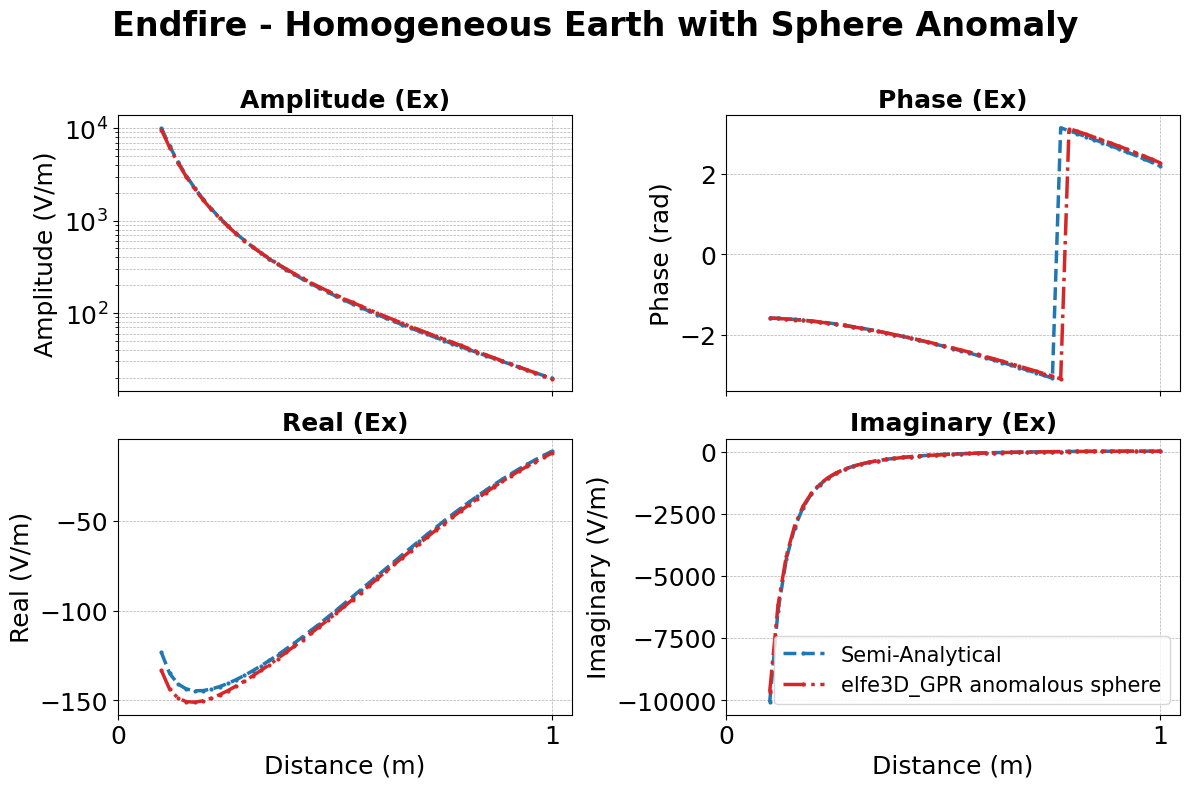

In [7]:
ReceiverLinePlot([semi_analytical, ef]).plot(suptitle="Endfire - Homogeneous Earth with Sphere Anomaly")

### 7.2. Error plot

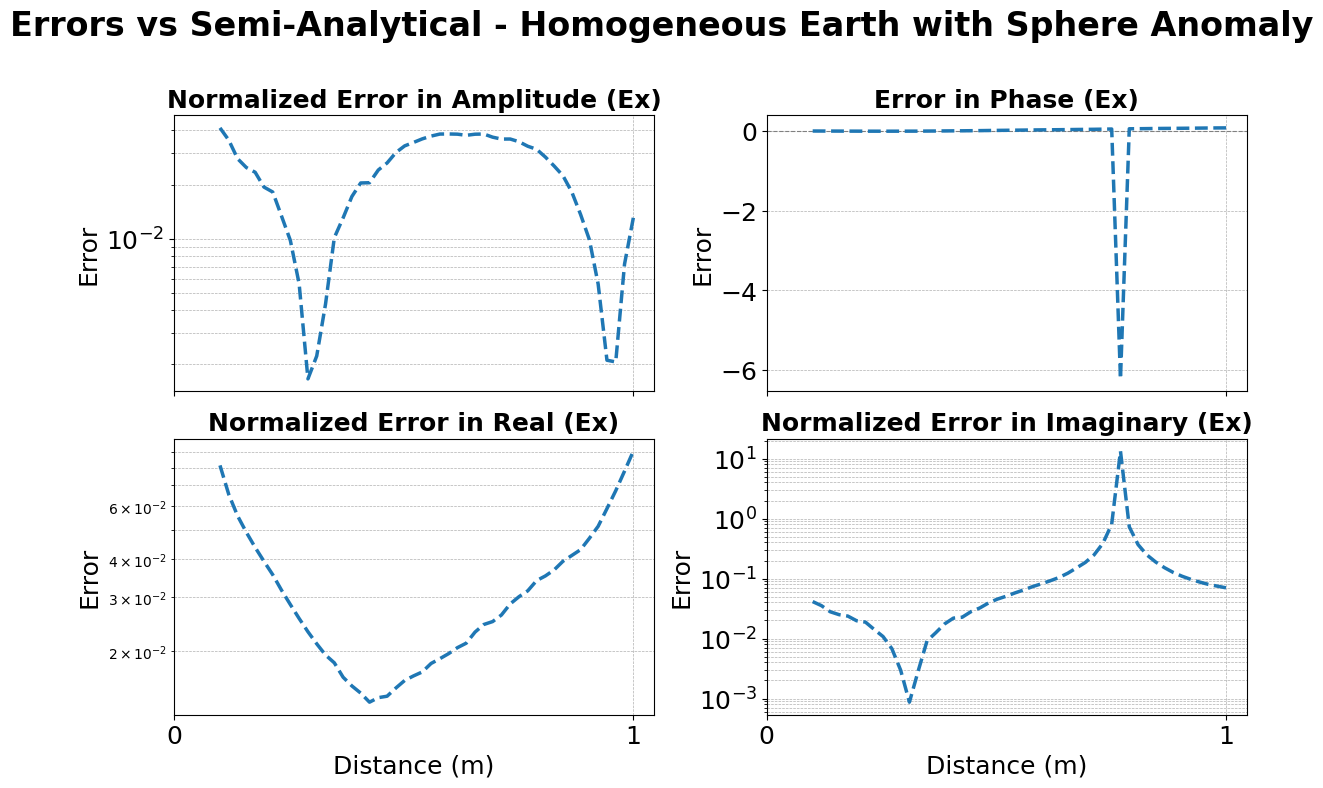

In [8]:
ReceiverLineErrorPlot([ef], reference=semi_analytical).plot(suptitle="Errors vs Semi-Analytical - Homogeneous Earth with Sphere Anomaly")

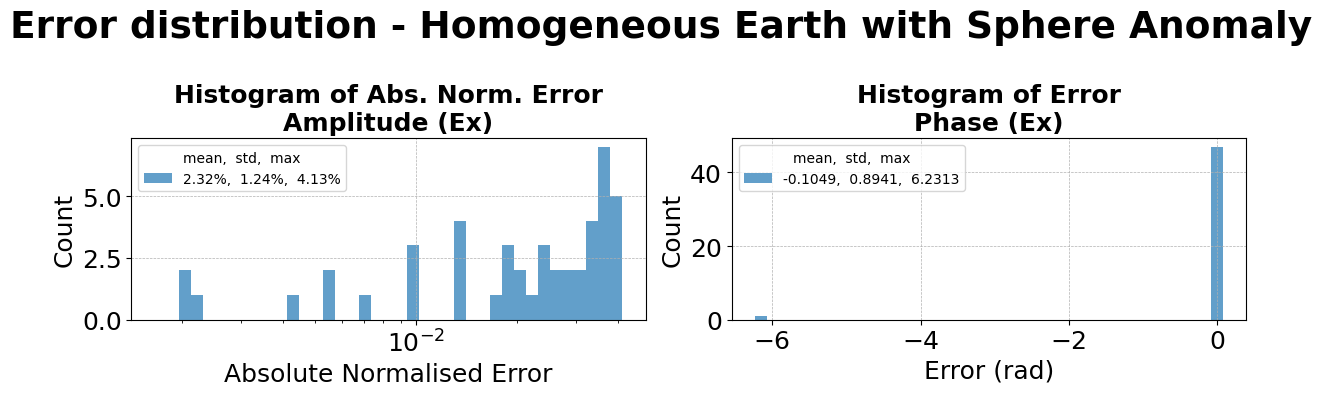

In [9]:
ErrorHistogramPlot([ef], reference=semi_analytical).plot(suptitle='Error distribution - Homogeneous Earth with Sphere Anomaly')

It is noticeable that the error in this anomalous sphere simulation is still considerably low. However, the fact that the error across the entire receiver line is rarely below 1% implies either that the semi-analytical solution's approximations struggle to solve the sphere scattering adequately, or that the simulation needs a finer discretization or PML thickness.

## 9. Conclusions

In this notebook we demonstrated how to solve a sphere subsurface anomaly problem in `elfe3D_GPR` using the I/O module, and compared against an approximate semi-analytical sphere solution.